In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
data=pd.read_csv(r"C:\Users\Harish\Desktop\customer_segmentation_project\data\customer_segmentation_dataset.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Phone_Number,Email_ID
0,1,Male,19,15,39,9800000000,customer1@example.com
1,2,Male,21,15,81,9800000001,customer2@example.com
2,3,Female,20,16,6,9800000002,customer3@example.com
3,4,Female,23,16,77,9800000003,customer4@example.com
4,5,Female,31,17,40,9800000004,customer5@example.com


In [48]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Phone_Number
count,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,100.500000,38.850000,60.560000,50.200000,9.800000e+09
std,57.879185,13.969007,26.264721,25.823522,5.787918e+01
min,1.000000,18.000000,15.000000,1.000000,9.800000e+09
25%,50.750000,28.750000,41.500000,34.750000,9.800000e+09
50%,100.500000,36.000000,61.500000,50.000000,9.800000e+09
75%,150.250000,49.000000,78.000000,73.000000,9.800000e+09
max,200.000000,70.000000,137.000000,99.000000,9.800000e+09


In [49]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Phone_Number              0
Email_ID                  0
dtype: int64

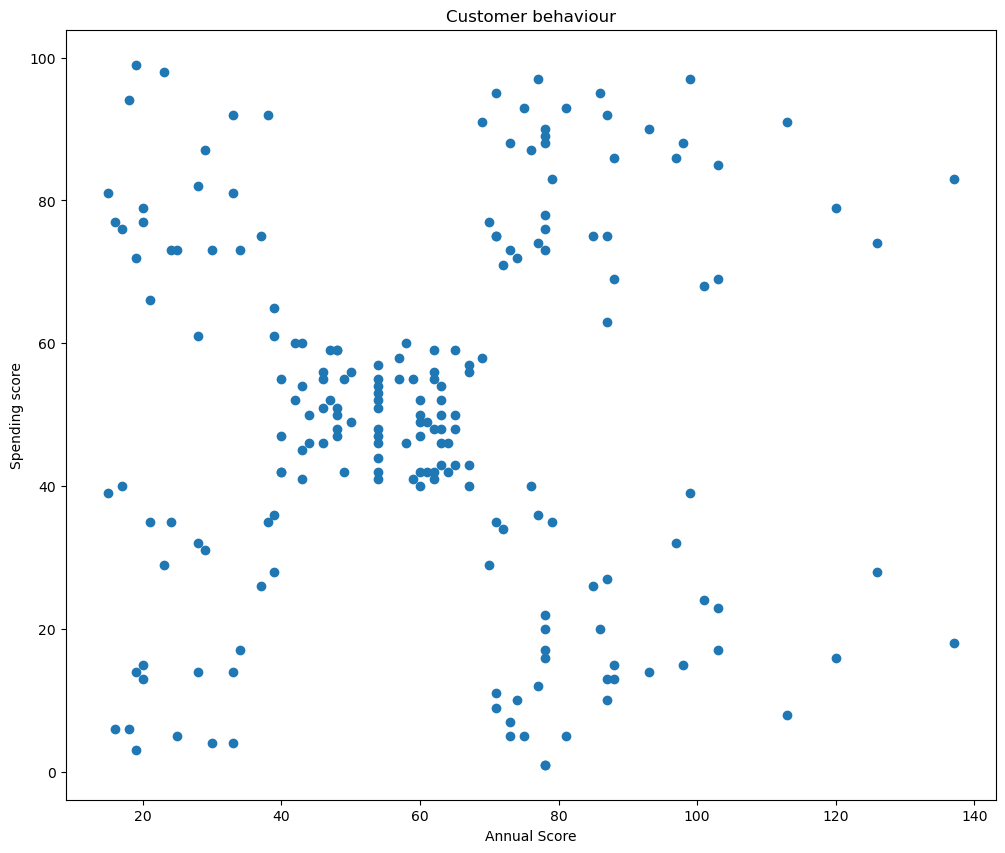

In [50]:
plt.figure(figsize=(12,10))
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'])
plt.xlabel("Annual Score")
plt.ylabel("Spending score")
plt.title("Customer behaviour")
plt.show()

In [51]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


C:\Users\Harish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Harish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Harish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Harish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

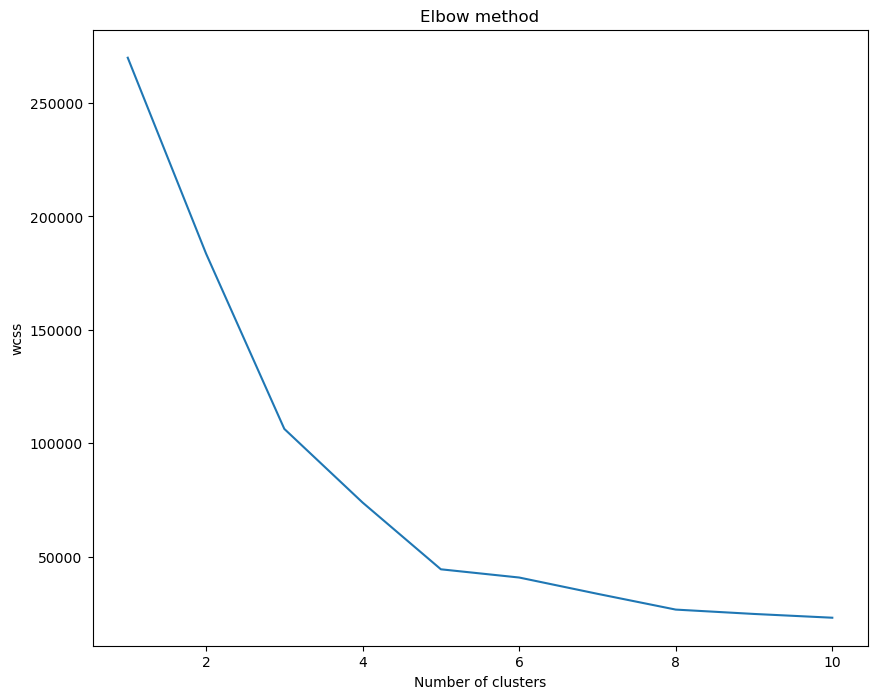

In [52]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10,8))
plt.plot(range(1,11),wcss)
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.show()

In [53]:
kmeans=KMeans(n_clusters=5,random_state=42)
y_kmeans=kmeans.fit_predict(X)
data['clusters']=y_kmeans
data.head()

C:\Users\Harish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Phone_Number,Email_ID,clusters
0,1,Male,19,15,39,9800000000,customer1@example.com,4
1,2,Male,21,15,81,9800000001,customer2@example.com,2
2,3,Female,20,16,6,9800000002,customer3@example.com,4
3,4,Female,23,16,77,9800000003,customer4@example.com,2
4,5,Female,31,17,40,9800000004,customer5@example.com,4


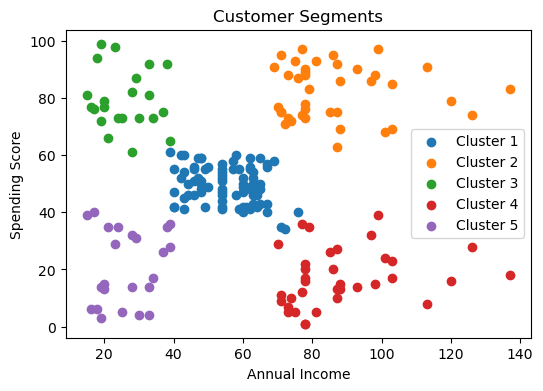

In [54]:
plt.figure(figsize=(6,4))
plt.scatter(X.iloc[y_kmeans == 0, 0], X.iloc[y_kmeans == 0, 1], label="Cluster 1")
plt.scatter(X.iloc[y_kmeans == 1, 0], X.iloc[y_kmeans == 1, 1], label="Cluster 2")
plt.scatter(X.iloc[y_kmeans == 2, 0], X.iloc[y_kmeans == 2, 1], label="Cluster 3")
plt.scatter(X.iloc[y_kmeans == 3, 0], X.iloc[y_kmeans == 3, 1], label="Cluster 4")
plt.scatter(X.iloc[y_kmeans == 4, 0], X.iloc[y_kmeans == 4, 1], label="Cluster 5")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.legend()
plt.show()

In [55]:
def label_cluster(cluster):
    if cluster == 1:
        return "Average Customers"
    elif cluster == 2:
        return "Premium Customers"
    elif cluster == 3:
        return "High Potential"
    elif cluster == 4:
        return "Careful Spenders"
    else: 
        return "Budget Customers"
data['Customer Type'] = data['clusters'].apply(label_cluster)
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Phone_Number,Email_ID,clusters,Customer Type
0,1,Male,19,15,39,9800000000,customer1@example.com,4,Careful Spenders
1,2,Male,21,15,81,9800000001,customer2@example.com,2,Premium Customers
2,3,Female,20,16,6,9800000002,customer3@example.com,4,Careful Spenders
3,4,Female,23,16,77,9800000003,customer4@example.com,2,Premium Customers
4,5,Female,31,17,40,9800000004,customer5@example.com,4,Careful Spenders


In [56]:
data['Customer Type'].value_counts()

Customer Type
Budget Customers     81
Average Customers    39
High Potential       35
Careful Spenders     23
Premium Customers    22
Name: count, dtype: int64

In [57]:
def get_action(segment):
    if segment == "Premium Customers":
        return "Retain: VIP offers, loyalty programs, early access"
    elif segment == "High Potential":
        return "Upsell: Recommend premium products, EMI options"
    elif segment == "Careful Spenders":
        return "Convert: Luxury marketing, personalized persuasion"
    elif segment == "Average Customers":
        return "Engage: Seasonal offers, product discovery campaigns"
    else:
        return "Boost: Discounts, combo offers, budget deals"
data['Business action']=data['Customer Type'].apply(get_action)

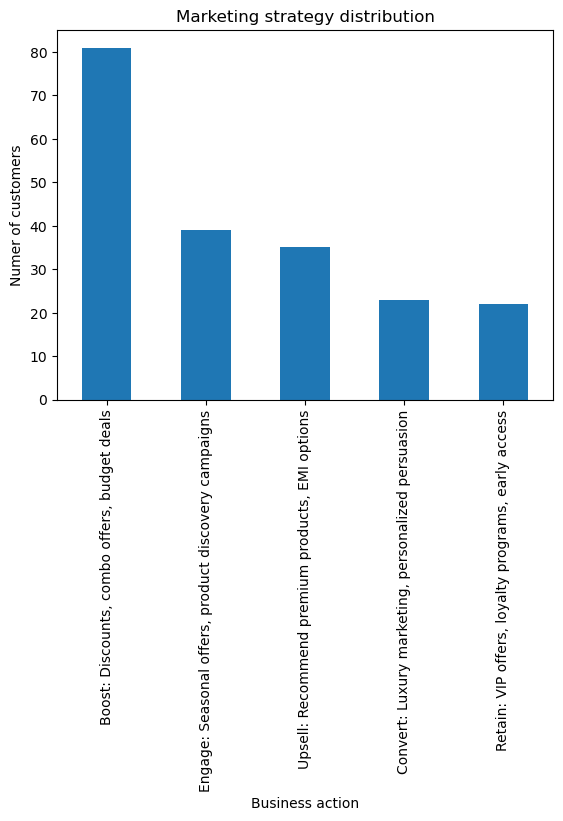

In [58]:
data['Business action'].value_counts().plot(kind='bar')
plt.title('Marketing strategy distribution')
plt.ylabel("Numer of customers")
plt.show()

In [59]:
boost_df    = data[data['Business action'] == 'Boost: Discounts, combo offers, budget deals']
engage_df   = data[data['Business action'] == 'Engage: Seasonal offers, product discovery campaigns']
upsell_df   = data[data['Business action'] == 'Upsell: Recommend premium products, EMI options']
convert_df  = data[data['Business action'] == 'Convert: Luxury marketing, personalized persuasion']
retain_df   = data[data['Business action'] == 'Retain: VIP offers, loyalty programs, early access']
print("Boost:",   len(boost_df))
print("Engage:",  len(engage_df))
print("Upsell:",  len(upsell_df))
print("Convert:", len(convert_df))
print("Retain:",  len(retain_df))

Boost: 81
Engage: 39
Upsell: 35
Convert: 23
Retain: 22


In [60]:
boost_df.to_csv(r"C:\Users\Harish\Desktop\customer_segmentation_project\outputs\boost_customers.csv",   index=False)
engage_df.to_csv(r"C:\Users\Harish\Desktop\customer_segmentation_project\outputs\engage_customers.csv", index=False)
upsell_df.to_csv(r"C:\Users\Harish\Desktop\customer_segmentation_project\outputs\upsell_customers.csv", index=False)
convert_df.to_csv(r"C:\Users\Harish\Desktop\customer_segmentation_project\outputs\convert_customers.csv", index=False)
retain_df.to_csv(r"C:\Users\Harish\Desktop\customer_segmentation_project\outputs\retain_customers.csv", index=False)
print("All segments exported successfully!")

All segments exported successfully!


In [74]:
print(boost_df[['CustomerID', 'Phone_Number', 'Email_ID', 'Customer Type', 'Business action']].head().to_string(index=False))

 CustomerID  Phone_Number               Email_ID    Customer Type                              Business action
         44    9800000043 customer44@example.com Budget Customers Boost: Discounts, combo offers, budget deals
         47    9800000046 customer47@example.com Budget Customers Boost: Discounts, combo offers, budget deals
         48    9800000047 customer48@example.com Budget Customers Boost: Discounts, combo offers, budget deals
         49    9800000048 customer49@example.com Budget Customers Boost: Discounts, combo offers, budget deals
         50    9800000049 customer50@example.com Budget Customers Boost: Discounts, combo offers, budget deals


In [75]:
print(engage_df[['CustomerID', 'Phone_Number', 'Email_ID', 'Customer Type', 'Business action']].head().to_string(index=False))

 CustomerID  Phone_Number                Email_ID     Customer Type                                      Business action
        124    9800000123 customer124@example.com Average Customers Engage: Seasonal offers, product discovery campaigns
        126    9800000125 customer126@example.com Average Customers Engage: Seasonal offers, product discovery campaigns
        128    9800000127 customer128@example.com Average Customers Engage: Seasonal offers, product discovery campaigns
        130    9800000129 customer130@example.com Average Customers Engage: Seasonal offers, product discovery campaigns
        132    9800000131 customer132@example.com Average Customers Engage: Seasonal offers, product discovery campaigns


In [77]:
print(upsell_df[['CustomerID', 'Phone_Number', 'Email_ID', 'Customer Type', 'Business action']].head().to_string(index=False))

 CustomerID  Phone_Number                Email_ID  Customer Type                                 Business action
        125    9800000124 customer125@example.com High Potential Upsell: Recommend premium products, EMI options
        129    9800000128 customer129@example.com High Potential Upsell: Recommend premium products, EMI options
        131    9800000130 customer131@example.com High Potential Upsell: Recommend premium products, EMI options
        135    9800000134 customer135@example.com High Potential Upsell: Recommend premium products, EMI options
        137    9800000136 customer137@example.com High Potential Upsell: Recommend premium products, EMI options


In [78]:
print(convert_df[['CustomerID', 'Phone_Number', 'Email_ID', 'Customer Type', 'Business action']].head().to_string(index=False))

 CustomerID  Phone_Number              Email_ID    Customer Type                                    Business action
          1    9800000000 customer1@example.com Careful Spenders Convert: Luxury marketing, personalized persuasion
          3    9800000002 customer3@example.com Careful Spenders Convert: Luxury marketing, personalized persuasion
          5    9800000004 customer5@example.com Careful Spenders Convert: Luxury marketing, personalized persuasion
          7    9800000006 customer7@example.com Careful Spenders Convert: Luxury marketing, personalized persuasion
          9    9800000008 customer9@example.com Careful Spenders Convert: Luxury marketing, personalized persuasion


In [79]:
print(retain_df[['CustomerID', 'Phone_Number', 'Email_ID', 'Customer Type', 'Business action']].head().to_string(index=False))

 CustomerID  Phone_Number               Email_ID     Customer Type                                    Business action
          2    9800000001  customer2@example.com Premium Customers Retain: VIP offers, loyalty programs, early access
          4    9800000003  customer4@example.com Premium Customers Retain: VIP offers, loyalty programs, early access
          6    9800000005  customer6@example.com Premium Customers Retain: VIP offers, loyalty programs, early access
          8    9800000007  customer8@example.com Premium Customers Retain: VIP offers, loyalty programs, early access
         10    9800000009 customer10@example.com Premium Customers Retain: VIP offers, loyalty programs, early access
